In [116]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

TEXTURE_FEATURES_3D = [
    # GLCM features
    "3GLCM_ACOR", "3GLCM_ASM", "3GLCM_CLUPROM", "3GLCM_CLUSHADE", "3GLCM_CLUTEND",
    "3GLCM_CONTRAST", "3GLCM_CORRELATION", "3GLCM_DIFAVE", "3GLCM_DIFENTRO", "3GLCM_DIFVAR",
    "3GLCM_DIS", "3GLCM_ENERGY", "3GLCM_ENTROPY", "3GLCM_HOM1", "3GLCM_HOM2",
    "3GLCM_ID", "3GLCM_IDN", "3GLCM_IDM", "3GLCM_IDMN", "3GLCM_INFOMEAS1", "3GLCM_INFOMEAS2",
    "3GLCM_IV", "3GLCM_JAVE", "3GLCM_JE", "3GLCM_JMAX", "3GLCM_JVAR",
    "3GLCM_SUMAVERAGE", "3GLCM_SUMENTROPY", "3GLCM_SUMVARIANCE", "3GLCM_VARIANCE",
    "3GLCM_ASM_AVE", "3GLCM_ACOR_AVE", "3GLCM_CLUPROM_AVE", "3GLCM_CLUSHADE_AVE",
    "3GLCM_CLUTEND_AVE", "3GLCM_CONTRAST_AVE", "3GLCM_CORRELATION_AVE",
    "3GLCM_DIFAVE_AVE", "3GLCM_DIFENTRO_AVE", "3GLCM_DIFVAR_AVE", "3GLCM_DIS_AVE",
    "3GLCM_ENERGY_AVE", "3GLCM_ENTROPY_AVE", "3GLCM_HOM1_AVE", "3GLCM_ID_AVE",
    "3GLCM_IDN_AVE", "3GLCM_IDM_AVE", "3GLCM_IDMN_AVE", "3GLCM_IV_AVE",
    "3GLCM_JAVE_AVE", "3GLCM_JE_AVE", "3GLCM_INFOMEAS1_AVE", "3GLCM_INFOMEAS2_AVE",
    "3GLCM_VARIANCE_AVE", "3GLCM_JMAX_AVE", "3GLCM_JVAR_AVE",
    "3GLCM_SUMAVERAGE_AVE", "3GLCM_SUMENTROPY_AVE", "3GLCM_SUMVARIANCE_AVE",

    # GLRLM features
    "3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3GLRLM_RLN", "3GLRLM_RLNN",
    "3GLRLM_RP", "3GLRLM_GLV", "3GLRLM_RV", "3GLRLM_RE", "3GLRLM_LGLRE", "3GLRLM_HGLRE",
    "3GLRLM_SRLGLE", "3GLRLM_SRHGLE", "3GLRLM_LRLGLE", "3GLRLM_LRHGLE",
    "3GLRLM_SRE_AVE", "3GLRLM_LRE_AVE", "3GLRLM_GLN_AVE", "3GLRLM_GLNN_AVE",
    "3GLRLM_RLN_AVE", "3GLRLM_RLNN_AVE", "3GLRLM_RP_AVE", "3GLRLM_GLV_AVE",
    "3GLRLM_RV_AVE", "3GLRLM_RE_AVE", "3GLRLM_LGLRE_AVE", "3GLRLM_HGLRE_AVE",
    "3GLRLM_SRLGLE_AVE", "3GLRLM_SRHGLE_AVE", "3GLRLM_LRLGLE_AVE", "3GLRLM_LRHGLE_AVE",

    # GLSZM features
    "GLSZM_SAE", "GLSZM_LAE", "GLSZM_GLN", "GLSZM_GLNN", "GLSZM_SZN", "GLSZM_SZNN",
    "GLSZM_ZP", "GLSZM_GLV", "GLSZM_ZV", "GLSZM_ZE", "GLSZM_LGLZE", "GLSZM_HGLZE",
    "GLSZM_SALGLE", "GLSZM_SAHGLE", "GLSZM_LALGLE", "GLSZM_LAHGLE",

    # GLDM features
    "3GLDM_SDE", "3GLDM_LDE", "3GLDM_GLN", "3GLDM_DN", "3GLDM_DNN", "3GLDM_GLV",
    "3GLDM_DV", "3GLDM_DE", "3GLDM_LGLE", "3GLDM_HGLE", "3GLDM_SDLGLE", "3GLDM_SDHGLE",
    "3GLDM_LDLGLE", "3GLDM_LDHGLE",

    # GLDZM features
    "3GLDZM_SDE", "3GLDZM_LDE", "3GLDZM_LGLZE", "3GLDZM_HGLZE", "3GLDZM_SDLGLE",
    "3GLDZM_SDHGLE", "3GLDZM_LDLGLE", "3GLDZM_LDHGLE", "3GLDZM_GLNU", "3GLDZM_GLNUN",
    "3GLDZM_ZDNU", "3GLDZM_ZDNUN", "3GLDZM_ZP", "3GLDZM_GLM", "3GLDZM_GLV",
    "3GLDZM_ZDM", "3GLDZM_ZDV", "3GLDZM_ZDE",

    # NGLDM features
    "3NGLDM_LDE", "3NGLDM_HDE", "3NGLDM_LGLCE", "3NGLDM_HGLCE", "3NGLDM_LDLGLE",
    "3NGLDM_LDHGLE", "3NGLDM_HDLGLE", "3NGLDM_HDHGLE", "3NGLDM_GLNU", "3NGLDM_GLNUN",
    "3NGLDM_DCNU", "3NGLDM_DCNUN", "3NGLDM_DCP", "3NGLDM_GLM", "3NGLDM_GLV",
    "3NGLDM_DCM", "3NGLDM_DCV", "3NGLDM_DCENT", "3NGLDM_DCENE",

    # NGTDM features
    "3NGTDM_COARSENESS", "3NGTDM_CONTRAST", "3NGTDM_BUSYNESS", "3NGTDM_COMPLEXITY",
    "3NGTDM_STRENGTH",
]

In [117]:

def read_features(features_dir: str) -> pd.DataFrame:
    """Read features from a directory.
    
    Args:
        features_dir: Directory containing features
        
    Returns:
        DataFrame containing all features
    """
    features = []
    for file in os.listdir(features_dir):
        df = pd.read_csv(os.path.join(features_dir, file))
        features.append(df)
    return pd.concat(features, ignore_index=True)

In [118]:
original_features_dir = "../../datasets/Craig_scans/original_features"
normalized_features_dir = "../../datasets/Craig_scans/nyul_normalized_features"

original_features = read_features(original_features_dir)
normalized_features = read_features(normalized_features_dir)

print(original_features.head())
print(normalized_features.head())




               intensity_image                                     mask_image  \
0  human_brain_20130613.nii.gz  human_brain_20130613_white_matter_mask.nii.gz   
1  human_brain_20100513.nii.gz  human_brain_20100513_white_matter_mask.nii.gz   
2  human_brain_20100304.nii.gz  human_brain_20100304_white_matter_mask.nii.gz   
3  human_brain_20130403.nii.gz  human_brain_20130403_white_matter_mask.nii.gz   
4  human_brain_20121108.nii.gz  human_brain_20121108_white_matter_mask.nii.gz   

   ROI_label      3COV  3COVERED_IMAGE_INTENSITY_RANGE       3ENERGY  \
0        1.0  0.164169                             1.0  1.035544e+12   
1        1.0  0.168022                             1.0  1.075120e+12   
2        1.0  0.316140                             1.0  1.130676e+11   
3        1.0  0.174457                             1.0  1.031744e+12   
4        1.0  0.168563                             1.0  1.027106e+12   

   3ENTROPY  3EXCESS_KURTOSIS  3HYPERFLATNESS  3HYPERSKEWNESS  ...  \
0  1.11296

In [119]:
def select_features(features: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    """Select features from a DataFrame.
    
    Args:
        features: DataFrame containing features
        feature_list: List of feature names to select
        
    Returns:
        DataFrame containing selected features
    """ 
    return features[feature_list]


original_features = select_features(original_features, TEXTURE_FEATURES_3D)
normalized_features = select_features(normalized_features, TEXTURE_FEATURES_3D)

print(original_features.head())
print(normalized_features.head())

   3GLCM_ACOR  3GLCM_ASM  3GLCM_CLUPROM  3GLCM_CLUSHADE  3GLCM_CLUTEND  \
0   11.986884   0.835337   20201.613277      757.170917      36.218521   
1   10.297098   0.831224   13827.612632      554.523861      29.741751   
2    2.653512   0.981115   12952.504012      255.193546       6.628741   
3   10.350894   0.850990   17517.546326      648.019270      31.000971   
4    9.983910   0.853583   15948.460590      612.138031      29.796409   

   3GLCM_CONTRAST  3GLCM_CORRELATION  3GLCM_DIFAVE  3GLCM_DIFENTRO  \
0        2.422727           0.874604      0.261478        0.447944   
1        1.699496           0.891894      0.210556        0.410347   
2        0.959393           0.747133      0.073041        0.097283   
3        2.108318           0.872645      0.233450        0.411515   
4        2.070599           0.870047      0.228817        0.401463   

   3GLCM_DIFVAR  ...  3NGLDM_GLV  3NGLDM_DCM  3NGLDM_DCV  3NGLDM_DCENT  \
0      2.354357  ...    3.536638   23.394537   20.808518    

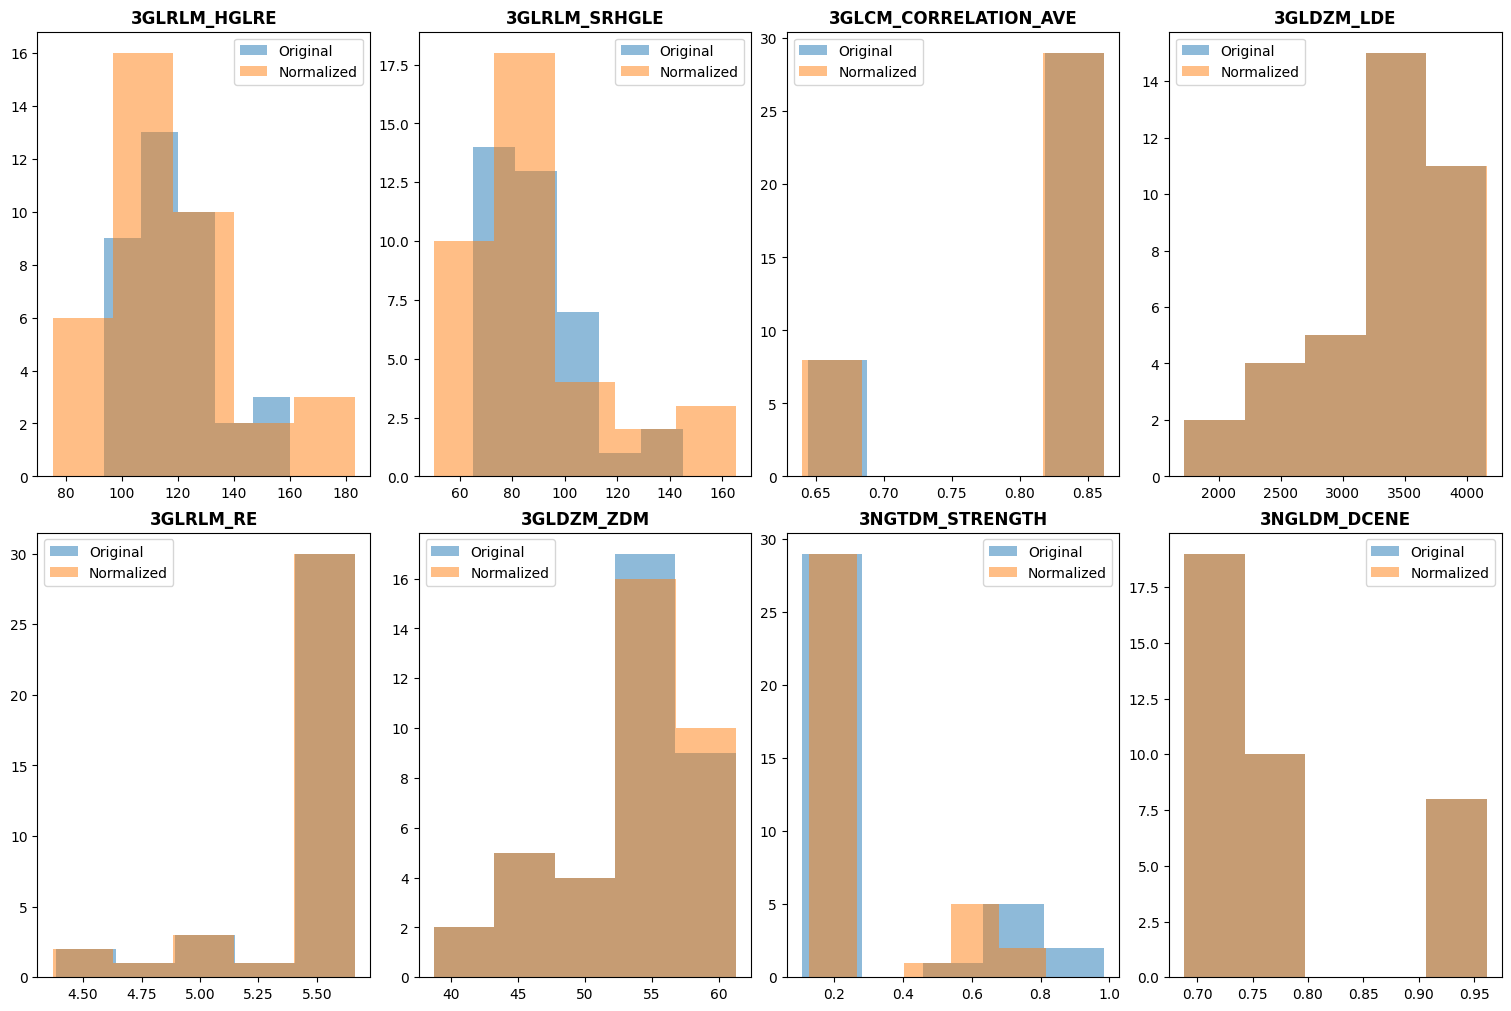

In [175]:
import matplotlib.pyplot as plt
num_bins = 5
fig, axs = plt.subplots(2, 4, figsize=(15, 10), constrained_layout=True)
cnt = 0 
sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', '3NGTDM_STRENGTH', '3NGLDM_DCENE']
for feature in sample_features:
    # print(f"Shape: {data.shape}, Values > {filter_threshold}: {len(filtered_data)}")

    axs[cnt//4, cnt%4].hist(original_features[feature],  bins=num_bins, alpha=0.5, label='Original')
    axs[cnt//4, cnt%4].hist(normalized_features[feature], bins=num_bins, alpha=0.5, label='Normalized')
    axs[cnt//4, cnt%4].set_title(feature, fontsize=12, fontweight='bold')
    # axs[cnt//3, cnt%3].set_xlabel('Signal Intensity')
    # axs[cnt//3, cnt%3].set_ylabel('Frequency')
    axs[cnt//4, cnt%4].legend()
    cnt += 1

# plt.legend()
plt.savefig("3D_texture_features_hist.png")
plt.show()

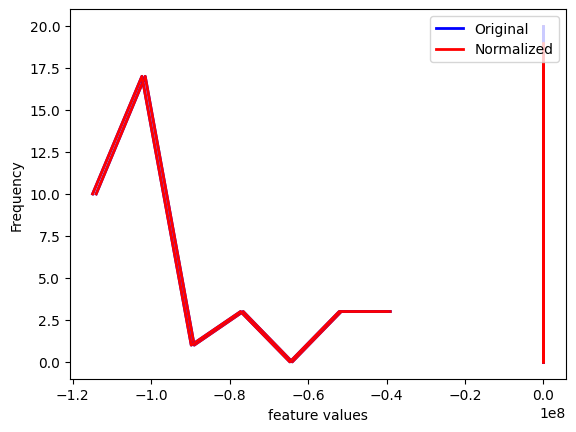

In [ ]:
num_bins = 7
for idx, feature in enumerate(TEXTURE_FEATURES_3D_negative):
    # plot the histogram of the original image
    # print(original_features[feature])
    hist_values, bin_edges = np.histogram(original_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
# plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 5000)
# plt.ylim(0, 5e5)
plt.xlabel('feature values')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig('feature_histogram_comparison_negative.png')
plt.show()

In [121]:
TEXTURE_FEATURES_3D_positive = [feature for feature in TEXTURE_FEATURES_3D if original_features[feature].min() > 0]
TEXTURE_FEATURES_3D_negative = list(set(TEXTURE_FEATURES_3D) - set(TEXTURE_FEATURES_3D_positive))
    

In [122]:
print("Negative features: ", len(TEXTURE_FEATURES_3D_negative))
print("Positive features: ", len(TEXTURE_FEATURES_3D_positive))


for idx, feature in enumerate(TEXTURE_FEATURES_3D_negative):
    print(original_features[feature].shape)

Negative features:  4
Positive features:  159
(37,)
(37,)
(37,)
(37,)


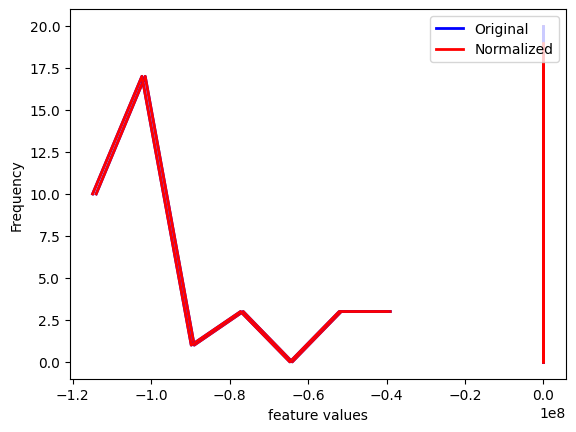

In [123]:
num_bins = 7
for idx, feature in enumerate(TEXTURE_FEATURES_3D_negative):
    # plot the histogram of the original image
    # print(original_features[feature])
    hist_values, bin_edges = np.histogram(original_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
# plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 5000)
# plt.ylim(0, 5e5)
plt.xlabel('feature values')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig('feature_histogram_comparison_negative.png')
plt.show()

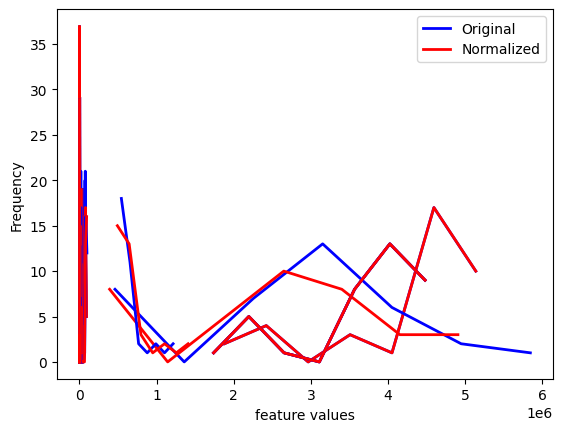

In [124]:
num_bins = 7
for idx, feature in enumerate(TEXTURE_FEATURES_3D_positive):
    # plot the histogram of the original image
    hist_values, bin_edges = np.histogram(original_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_features[feature], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
# plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 5000)
# plt.ylim(0, 5e5)
plt.xlabel('feature values')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig('feature_histogram_comparison_positive.png')
plt.show()

In [169]:
# Calculate significance for a single feature
def f_test_variance(feature_name, original_df, normalized_df, alpha=0.05) -> bool:
    var_original = np.var(original_df[feature_name], ddof=1)
    var_normalized = np.var(normalized_df[feature_name], ddof=1)
    
    f_stat = var_original / var_normalized
    n1, n2 = len(original_df), len(normalized_df)
    dfn, dfd = n1 - 1, n2 - 1
    # Calculate p-value for two-tailed F-test
    p_value = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
    
    # print(f"Feature: {feature_name}")
    # print(f"Original variance: {var_original:.6f}")
    # print(f"Normalized variance: {var_normalized:.6f}")
    # print(f"F-statistic: {f_stat:.6f}")
    # print(f"p-value: {p_value:.6f}")
    # print("Interpretation:", end=" ")
    if p_value < alpha:
        if f_stat > 1:
            print("Original has significantly higher variance")
        else:
            print("Normalized has significantly higher variance")
        return True
    else:
        print("No significant difference in variances")


# Example usage for first few features
significant_features = []
for feature in TEXTURE_FEATURES_3D:
    if f_test_variance(feature, original_features, normalized_features):
        significant_features.append(feature)
print(f"Number of features with a significant difference in variance: {len(significant_features)}, significant features: {significant_features}")

No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference in variances
No significant difference

/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_29325/673664096.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f_stat = var_original / var_normalized


In [171]:
def compare_features_wilcoxon(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                              feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform Wilcoxon signed-rank test to compare original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Perform Wilcoxon test
            stat, p_value = stats.wilcoxon(original_df[feature], 
                                         normalized_df[feature],
                                         alternative='two-sided')
            
            # Calculate effect size
            n = len(original_df[feature])
            z_score = stats.norm.ppf(p_value / 2)
            
            # r < 0.1: Negligible effect
            # 0.1 ≤ r < 0.3: Small effect
            # 0.3 ≤ r < 0.5: Medium effect
            # r ≥ 0.5: Large effect
            effect_size = abs(z_score) / np.sqrt(n)
            
            # Determine direction
            mean_diff = np.mean(original_df[feature] - normalized_df[feature])
            direction = "higher" if mean_diff > 0 else "lower"
            
            results.append({
                'feature_name': feature,
                'statistic': stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'effect_size': effect_size,
                'original_vs_normalized': f"Original {direction} than normalized"
            })
    
    return pd.DataFrame(results).sort_values('p_value')

# Run the comparison
wilcoxon_results = compare_features_wilcoxon(original_features, normalized_features, 
                                           TEXTURE_FEATURES_3D)

# Show results
print("\nFeatures with significant differences (p < 0.05):")
significant = wilcoxon_results[wilcoxon_results['significant']]
print(f" Number of significant features: {significant.shape[0]}")
print(significant['feature_name'].tolist())
#print(significant[['featur e_name', 'p_value', 'effect_size', 'original_vs_normalized']].head())



Features with significant differences (p < 0.05):
 Number of significant features: 5
['3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', '3GLRLM_RE_AVE']


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [127]:
def perform_anova_test(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                      feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform one-way ANOVA test between original and normalized features.
    """
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Calculate basic statistics
            orig_mean = np.mean(original_df[feature])
            norm_mean = np.mean(normalized_df[feature])
            orig_var = np.var(original_df[feature], ddof=1)
            norm_var = np.var(normalized_df[feature], ddof=1)
            
            # Perform one-way ANOVA
            f_stat, p_value = stats.f_oneway(original_df[feature], 
                                           normalized_df[feature])
            
            # Calculate effect size (eta-squared)
            # η² = SSbetween / SStotal
            groups = [original_df[feature], normalized_df[feature]]
            grand_mean = np.mean([orig_mean, norm_mean])
            ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
            ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
            eta_squared = ss_between / ss_total if ss_total != 0 else 0
            
            # The effect size thresholds (0.01, 0.06, 0.14) for eta-squared (η²)
            #  come from established statistical guidelines by Cohen (1988) and later researchers.
            if eta_squared < 0.01:
                effect_size_interp = "negligible"
            elif eta_squared < 0.06:
                effect_size_interp = "small"
            elif eta_squared < 0.14:
                effect_size_interp = "medium"
            else:
                effect_size_interp = "large"
            
            results.append({
                'feature_name': feature,
                'original_mean': orig_mean,
                'normalized_mean': norm_mean,
                'original_variance': orig_var,
                'normalized_variance': norm_var,
                'f_statistic': f_stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'eta_squared': eta_squared,
                'effect_size': effect_size_interp
            })
    
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("ANOVA Test Results Summary:")
    print(f"Total features tested: {len(results_df)}")
    print(f"Features with significant differences: {sum(results_df['significant'])}")
    print("\nEffect size distribution:")
    print(results_df['effect_size'].value_counts())
    
    # Visualization of significant differences
    significant_results = results_df[results_df['significant']].sort_values('p_value')
    
 
    
    return results_df.sort_values('p_value')

# Run ANOVA analysis
anova_results = perform_anova_test(original_features, normalized_features, TEXTURE_FEATURES_3D)

significant = anova_results[anova_results['significant']]
print(f" Number of significant features: {significant.shape[0]}")


ANOVA Test Results Summary:
Total features tested: 163
Features with significant differences: 0

Effect size distribution:
effect_size
negligible    163
Name: count, dtype: int64
 Number of significant features: 0


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [128]:
def calculate_kl_divergence(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                           feature_list: list[str], n_bins: int = 10) -> pd.DataFrame:
    """Calculate KL divergence between original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
          # Find common range for bins
            min_val = min(original_df[feature].min(), normalized_df[feature].min())
            max_val = max(original_df[feature].max(), normalized_df[feature].max())
            
            # Create common bins
            bins = np.linspace(min_val, max_val, n_bins + 1)
            
            # Use same bins for both histograms
            hist_orig, _ = np.histogram(original_df[feature], bins=bins, density=True)
            hist_norm, _ = np.histogram(normalized_df[feature], bins=bins, density=True)
            
            # Add small constant to avoid division by zero
            epsilon = 1e-10
            hist_orig = hist_orig + epsilon
            hist_norm = hist_norm + epsilon
            
            # Normalize
            hist_orig = hist_orig / hist_orig.sum()
            hist_norm = hist_norm / hist_norm.sum()
            
            # Calculate KL divergence
            kl_div = np.sum(hist_orig * np.log(hist_orig / hist_norm))
            
            results.append({
                'feature_name': feature,
                'kl_divergence': kl_div,
                'significant': kl_div > 1
            })
    
    return pd.DataFrame(results).sort_values('kl_divergence', ascending=False)



kl_results = calculate_kl_divergence(original_features, normalized_features, TEXTURE_FEATURES_3D)

print("top 10 features with highest distribution differences")
print(kl_results.sort_values('kl_divergence', ascending=False).head(10))
print("nyul 6000: ", kl_results['significant'].shape)


top 10 features with highest distribution differences
       feature_name  kl_divergence  significant
117    3GLDM_SDLGLE       3.587880         True
82   3GLRLM_GLV_AVE       3.089012         True
45    3GLCM_IDN_AVE       3.056140         True
144   3NGLDM_LDHGLE       2.670199         True
103    GLSZM_SALGLE       2.653910         True
127   3GLDZM_LDLGLE       2.645433         True
66       3GLRLM_GLV       2.573291         True
101     GLSZM_LGLZE       2.330052         True
16        3GLCM_IDN       2.323854         True
40    3GLCM_DIS_AVE       2.039933         True
nyul 6000:  (163,)


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_29325/1713825810.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_29325/1713825810.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_29325/1713825810.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normal

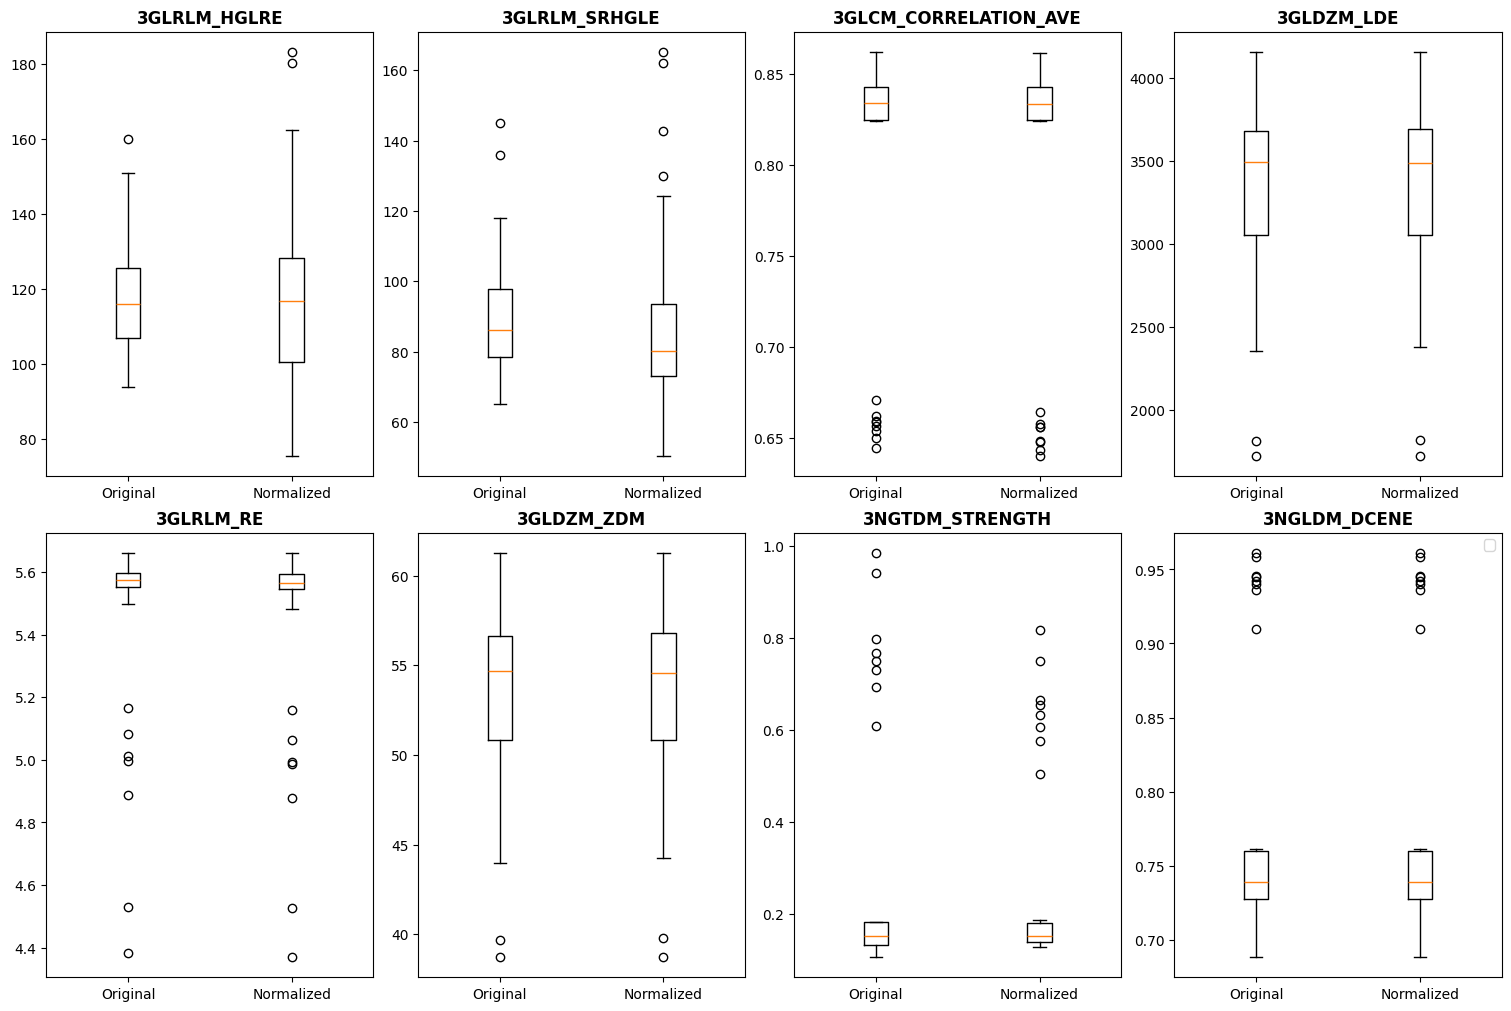

In [176]:
import matplotlib.pyplot as plt
num_bins = 7
num_cols = 4
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10), constrained_layout=True)
cnt = 0 
# sample_features = ["3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3NGTDM_COARSENESS", "3NGTDM_CONTRAST"]
# sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLRLM_HGLRE_AVE', '3GLRLM_GLNN', '3NGTDM_COARSENESS'] #, '3GLDM_LGLE', '3GLDM_HGLE', '3GLDM_SDLGLE', '3GLDZM_LGLZE', '3GLDZM_GLM'
#sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', "3GLRLM_SRE", "3GLRLM_LRE"]
sample_features = ['3GLRLM_HGLRE', '3GLRLM_SRHGLE', '3GLCM_CORRELATION_AVE', '3GLDZM_LDE', '3GLRLM_RE', '3GLDZM_ZDM', '3NGTDM_STRENGTH', '3NGLDM_DCENE']
for feature in sample_features:
    data = [original_features[feature], normalized_features[feature]]
    axs[cnt//num_cols, cnt%num_cols].boxplot(data, labels=['Original', 'Normalized'])
    axs[cnt//num_cols, cnt%num_cols].set_title(feature, fontsize=12, fontweight='bold')
    # # axs[cnt//3, cnt%3].set_xlabel('Signal Intensity')
    # # axs[cnt//3, cnt%3].set_ylabel('Frequency')
    # axs[cnt//4, cnt%4].legend()
    cnt += 1

plt.legend()
plt.savefig("3D_texture_features_boxplot.png")
plt.show()